# Project Overview

The main purpose of this project is to explore whether neural networks can learn to compress images better than classical codecs like JPEG and zlib.

Classical codecs use mathematical rules like frequency decomposition or pattern matching to compress things. A Variational Autoencoder (VAE) however, would learn the structure of a specific type of data from examples, and then use that to compress data more efficiently.

The core question is thus: on structured, domain-specific data, can a learned compressor beat a general purpose one?

In [1]:
import sys
import os
sys.path.insert(0, os.path.dirname(os.getcwd()))

import torch
import matplotlib.pyplot as plt
import numpy as np

from training.dataloader import get_dataloaders, get_input_dim, DATASET_INFO

## So, why MNIST?

There are three reasons for this.

1. It's fast. Each image is 28x28 pixels and grayscale, so training is pretty fast. We can iterate quickly: try something, see if it works, and adjust.
2. It's well understood. If the reconstructions look wrong, we'll know the problem is in the model, not in the data.
3. It's structured. This is the main reason honestly. All the images are digits on a plain background, and this kind of regularity is exactly what we want.

Maybe we'll move to more varied and complicated datasets like CIFAR-10 to see how the comparison against classical codecs changes, but that's for later.

In [2]:
train_loader, test_loader = get_dataloaders(dataset='mnist', data_dir='../data', batch_size=128)
images, labels = next(iter(train_loader))

print("Batch shape: ", images.shape)
print("Label shape: ", labels.shape)
print("Pixels min/max: ", images.min().item(), "to", images.max().item())
print("Pixels mean: ", images.mean().item())
print("Pixel std: ", images.std().item())

Batch shape:  torch.Size([128, 1, 28, 28])
Label shape:  torch.Size([128])
Pixels min/max:  0.0 to 1.0
Pixels mean:  0.12962806224822998
Pixel std:  0.306120902299881


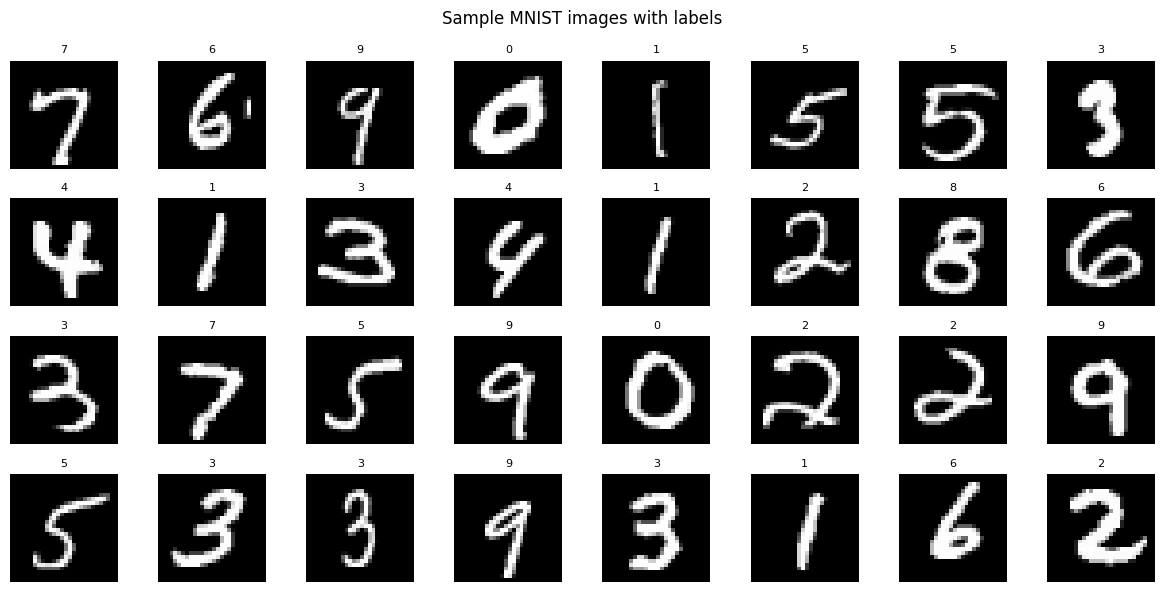

In [4]:
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
axes = axes.flatten()

for i in range(32):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].set_title(str(labels[i].item()), fontsize=8)
    axes[i].axis('off')

plt.suptitle('Sample MNIST images with labels')
plt.tight_layout()
plt.show()

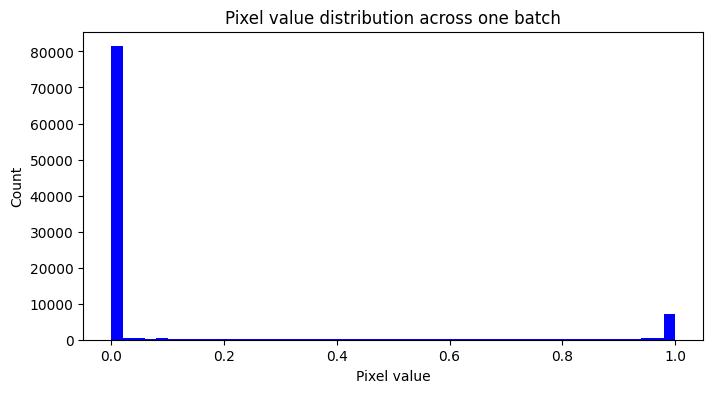

In [5]:
plt.figure(figsize=(8, 4))
plt.hist(images.numpy().flatten(), bins=50, color='blue', edgecolor='none')
plt.xlabel('Pixel value')
plt.ylabel('Count')
plt.title('Pixel value distribution across one batch')
plt.show()

Shape: sample.shape
Non-zero pixels:  133 out of 784


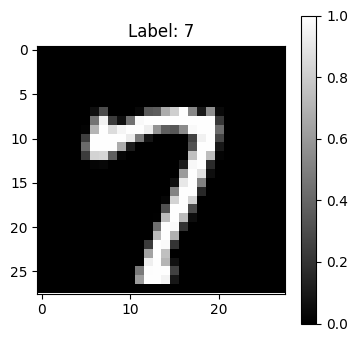

In [7]:
sample = images[0].squeeze()

print("Shape: sample.shape")
print("Non-zero pixels: ", (sample>0).sum().item(), "out of", sample.numel())

plt.figure(figsize=(4, 4))
plt.imshow(sample, cmap='gray')
plt.colorbar()
plt.title(f"Label: {labels[0].item()}")
plt.show()